---

<table style="width:100%">
  <tr>
    <th>
        <div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> Конспект лекцій з предмету: </p>
<p style="text-align: center;"><b><h2>"Електронні прилади та мікроелектроніка"</h2></b></p>
<p style="text-align: center;"><b><h3>Лекція 10. Динамічні властивості польових транзисторів. Потужні МДН-транзистори та IGBT</h3></b></p>
<p style="text-align: center;"> Національний університет "Чернігівська політехніка"</p>
<p style="text-align: center;"><b>Кафедра:</b> Радіотехніки та відеоінформаційних систем (РТВС)</p>
<hr/>
<p style="text-align: center;"><b>Теми лекції:</b></p>
<ul style="text-align: left;">
  <li>Ємності МДН-транзистора та гранична частота</li>
  <li>Перемикання МДН-транзистора: заряд затвора, плато Міллера, динамічні втрати</li>
  <li>Потужні вертикальні МДН-транзистори (VDMOS), внутрішній діод, опір увімкненого стану</li>
  <li>Широкозонні ключі: SiC і GaN</li>
  <li>IGBT: будова, еквівалентна схема, характеристики, «хвіст» струму, защіпання</li>
  <li>Порівняння силових ключів і області застосування</li>
</ul>
</div>
    </th>
    <th>
<div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> <b>Викладач:</b> </p>
<p style="text-align: center;"> Доктор філософії, Кафедра РТВС</p>
<p style="text-align: center;"> Пахалюк Богдан Петрович</p>
<img src="./Teacher.jpg" alt="" width="110" >
<hr/>
<p style="text-align: center; font-size: 0.9em;">Лекція 10 з 13</p>
</div>
    </th>
  </tr>
</table>

---

---

<p style="text-align: center;"><b>Зміст</b></p>

* [Ємності та частотні властивості МДН-транзистора](#mos-caps)
    * [⚙️ PySpice: ємності IRF540 як функція напруги стоку](#spice-caps)
* [Перемикання потужного МДН-транзистора](#mos-switching)
    * [⚙️ PySpice: осцилограми перемикання і заряд затвора IRF540](#spice-gate-charge)
* [Потужні вертикальні МДН-транзистори](#vdmos)
* [IGBT — біполярний транзистор з ізольованим затвором](#igbt)
    * [⚙️ PySpice: вихідні характеристики IGBT і МДН-транзистора](#spice-igbt-dc)
    * [⚙️ PySpice: вимикання IGBT і МДН-транзистора — «хвіст» струму](#spice-igbt-tail)
* [Порівняння силових ключів](#switch-comparison)
* [📌 Підсумок лекції](#summary)
* [📚 Рекомендована література](#references)

> 💡 Код демонстрацій та інтерактивних графіків **згорнуто**, щоб не відволікати від матеріалу. Щоб переглянути його, натисніть на «⋯» (або на смужку ліворуч від комірки). Для роботи інтерактивних елементів виконайте всі комірки: *Run → Run All Cells*. Позначка 🔬 — інтерактивне моделювання (повзунки), ⚙️ — моделювання схеми в **PySpice/ngspice**.

---

**Підключення бібліотек.** NumPy/Matplotlib — чисельні розрахунки та графіки, ipywidgets — інтерактивні повзунки, PySpice + ngspice — схемотехнічне моделювання, schemdraw — побудова схем з умовними позначеннями за ДСТУ/IEC. SPICE-моделі реальних приладів зібрано в теці `models/`. Цю комірку потрібно виконати першою.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='Unable to import Axes3D')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ipywidgets import interact, interactive, fixed, HBox, VBox, Output
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown
%matplotlib inline

import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging(logging_level='ERROR')
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

# ngspice ≥ 41 пише в stderr інформаційні повідомлення (напр. "Using SPARSE 1.3 as Direct Linear Solver"),
# які PySpice 1.5 вважає помилкою симуляції. Сприймаємо як помилку лише рядки, що містять "error".
from PySpice.Spice.NgSpice import Shared as _ngspice_shared
_orig_send_char = _ngspice_shared.NgSpiceShared._send_char
def _send_char(message_c, ngspice_id, user_data):
    message = _ngspice_shared.ffi_string_utf8(message_c)
    prefix, _, content = message.partition(' ')
    if prefix == 'stderr' and 'error' not in content.lower() and 'init file' not in content:
        self = _ngspice_shared.ffi.from_handle(user_data)
        self._stderr.append(content)
        return self.send_char(message, ngspice_id)
    return _orig_send_char(message_c, ngspice_id, user_data)
_ngspice_shared.NgSpiceShared._send_char = staticmethod(_send_char)

MODELS = 'models'   # тека з SPICE-моделями реальних приладів
def lib(name):
    """Шлях до бібліотеки моделей: lib('diodes') -> models/diodes.lib"""
    return f'{MODELS}/{name}.lib'

try:
    import schemdraw
    import schemdraw.elements as elm
    SCHEMDRAW_AVAILABLE = True
except ImportError:
    SCHEMDRAW_AVAILABLE = False
    print('schemdraw не встановлено (pip install schemdraw)')

plt.rcParams.update({
    'figure.figsize': (8, 4), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 12, 'axes.titlesize': 13, 'lines.linewidth': 2,
    'font.size': 11,
})

if SCHEMDRAW_AVAILABLE:
    # Умовні позначення за ДСТУ/IEC: резистор — прямокутник, джерело ЕРС — коло зі стрілкою
    from schemdraw.segments import Segment
    from schemdraw.elements.transistors import jfetw, fetl
    elm.style(elm.STYLE_IEC)

    class EMF(elm.Source):
        """Джерело ЕРС: стрілка всередині кола вказує напрямок дії ЕРС."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.2, 0), (.8, 0)], arrow='->', arrowwidth=.16, arrowlength=.25))

    class CurrentSource(elm.Source):
        """Джерело струму: подвійна стрілка вказує напрямок струму."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.15, 0), (.85, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))
            self.segments.append(Segment([(.15, 0), (.62, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))

    class JFetNch(elm.JFet):
        """Польовий транзистор з p-n переходом і каналом n-типу: стрілка затвора спрямована ДО каналу."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(jfetw + .3, -fetl - jfetw), (jfetw, -fetl - jfetw)],
                                         arrow='->', arrowwidth=.2, arrowlength=.25))

    class JFetPch(elm.JFet):
        """Польовий транзистор з p-n переходом і каналом p-типу: стрілка затвора спрямована ВІД каналу."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(jfetw + .05, -fetl - jfetw), (jfetw + .35, -fetl - jfetw)],
                                         arrow='->', arrowwidth=.2, arrowlength=.25))

# Фізичні сталі
q = 1.602176634e-19      # Кл, елементарний заряд
k_B = 1.380649e-23       # Дж/К, стала Больцмана
eps0 = 8.8541878128e-12  # Ф/м, електрична стала
def phi_T(T=300.0):
    """Температурний потенціал kT/q, В"""
    return k_B * T / q

def tran_checked(sim, end_time, **kw):
    """Перехідний аналіз з перевіркою: ngspice іноді зупиняється достроково («timestep too small»)."""
    an = sim.transient(end_time=end_time, **kw)
    t = np.array(an.time)
    if t[-1] < 0.999*end_time:
        raise RuntimeError(f'ngspice зупинився на t = {t[-1]:.3g} с — розрахунок не збігся')
    return an

---

# Ємності та частотні властивості МДН-транзистора <a class="anchor" id="mos-caps"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Пояснювати походження ємностей МДН-транзистора і їх довідникові позначення $C_{iss}$, $C_{oss}$, $C_{rss}$
> - Аналізувати процес перемикання потужного МДН-транзистора, плато Міллера і заряд затвора
> - Оцінювати статичні й динамічні втрати ключа
> - Пояснювати будову VDMOS, роль внутрішнього діода і компроміс між $R_{DS(on)}$ і напругою пробою
> - Пояснювати будову й принцип дії IGBT, його переваги й недоліки порівняно з МДН-транзистором
> - Обирати тип силового ключа за напругою, струмом і частотою

</div>


### 📖 Ключові поняття

| Поняття | Визначення |
|---------|-----------|
| **$C_{iss} = C_{ЗВ} + C_{ЗС}$** | Вхідна ємність (при закороченому по змінному струму стоку) |
| **$C_{oss} = C_{СВ} + C_{ЗС}$** | Вихідна ємність (при закороченому затворі) |
| **$C_{rss} = C_{ЗС}$** | Прохідна ємність (ємність Міллера) |
| **$Q_g$** | Повний заряд затвора, потрібний для перемикання |
| **$R_{DS(on)}$** | Опір відкритого каналу потужного МДН-транзистора |
| **IGBT** | Insulated Gate Bipolar Transistor — МДН-керування + біполярна провідність |

У МДН-транзистора три міжелектродні ємності: **затвор–витік** $C_{ЗВ}$ (оксид над каналом і перекриття затвора з витоком), **затвор–стік** $C_{ЗС}$ (перекриття затвора зі стоком) і **стік–витік** $C_{СВ}$ (бар'єрна ємність переходу стік–підкладка). У довідниках наводять виміряні комбінації:

$$C_{iss} = C_{ЗВ} + C_{ЗС}, \qquad C_{oss} = C_{СВ} + C_{ЗС}, \qquad C_{rss} = C_{ЗС}.$$

Ємності $C_{ЗС}$ і $C_{СВ}$ — бар'єрні, тому **сильно зменшуються** зі зростанням $U_{СВ}$ (у потужних транзисторів — на порядок). Швидкодію МДН-транзистора визначає лише перезаряд ємностей — інжекції і накопичення неосновних носіїв немає. Гранична частота

$$f_T = \frac{g_m}{2\pi(C_{ЗВ} + C_{ЗС})} \;\approx\; \frac{\mu_n\,(U_{ЗВ} - U_{пор})}{2\pi L^2}$$

обернено пропорційна **квадрату довжини каналу** — головна причина зменшення $L$ у сучасних технологіях (НВЧ МДН-транзистори мають $f_T$ сотні ГГц).

### ⚙️ PySpice: ємності IRF540 як функція напруги стоку <a class="anchor" id="spice-caps"></a>

Ємності «вимірюються» так само, як це робить характериограф: малий змінний сигнал 1 МГц на затворі (для $C_{iss}$, $C_{rss}$) або на стоці (для $C_{oss}$) при заданій постійній напрузі $U_{СВ}$ і $U_{ЗВ} = 0$.

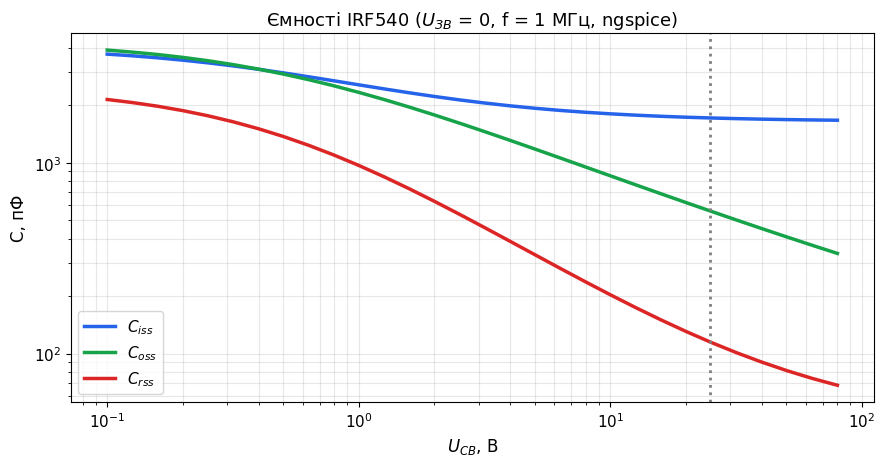

При U_СВ = 25 В: C_iss = 1715 пФ, C_oss = 556 пФ, C_rss = 114 пФ (паспорт IRF540: 1700 / 560 / 120 пФ)


In [2]:
def fet_caps(Uds, model='irf540_IR', f=1e6):
    w = 2*np.pi*f
    c = Circuit('Ciss/Crss'); c.include(lib('mosfet'))
    c.V('d', 'd', c.gnd, Uds); c.SinusoidalVoltageSource('g', 'g', c.gnd, ac_magnitude=1); c.X(1, model, 'd', 'g', c.gnd)
    an = c.simulator().ac(start_frequency=f, stop_frequency=10*f, number_of_points=1, variation='dec')
    Ig, Id = complex(np.array(an.branches['vg'])[0]), complex(np.array(an.branches['vd'])[0])
    c2 = Circuit('Coss'); c2.include(lib('mosfet'))
    c2.SinusoidalVoltageSource('d', 'd', c2.gnd, dc_offset=Uds, ac_magnitude=1); c2.V('g', 'g', c2.gnd, 0); c2.X(1, model, 'd', 'g', c2.gnd)
    an2 = c2.simulator().ac(start_frequency=f, stop_frequency=10*f, number_of_points=1, variation='dec')
    Io = complex(np.array(an2.branches['vd'])[0])
    return abs(Ig.imag)/w, abs(Io.imag)/w, abs(Id)/w

U = np.logspace(-1, np.log10(80), 30)
C = np.array([fet_caps(u) for u in U])
fig, ax = plt.subplots(figsize=(9, 4.8))
for k, (lab, col) in enumerate([('$C_{iss}$', '#2563eb'), ('$C_{oss}$', '#16a34a'), ('$C_{rss}$', '#dc2626')]):
    ax.loglog(U, C[:, k]*1e12, color=col, lw=2.5, label=lab)
ax.axvline(25, color='gray', ls=':'); ax.set_xlabel('$U_{СВ}$, В'); ax.set_ylabel('C, пФ'); ax.grid(True, which='both', alpha=0.3)
ax.set_title('Ємності IRF540 ($U_{ЗВ}$ = 0, f = 1 МГц, ngspice)'); ax.legend()
plt.tight_layout(); plt.show()
k = np.argmin(abs(U - 25))
print(f'При U_СВ = 25 В: C_iss = {C[k,0]*1e12:.0f} пФ, C_oss = {C[k,1]*1e12:.0f} пФ, C_rss = {C[k,2]*1e12:.0f} пФ '
      '(паспорт IRF540: 1700 / 560 / 120 пФ)')

---

# Перемикання потужного МДН-транзистора <a class="anchor" id="mos-switching"></a>

Драйвер заряджає вхідні ємності через опір затвора $R_З$ (внутрішній опір драйвера + зовнішній резистор + опір затвора в кристалі). При ввімкненні на резистивне або індуктивне навантаження розрізняють чотири етапи:

1. **Затримка** ($t_{d(on)}$) — $C_{ЗВ}$ заряджається до порогу $U_{пор}$; струму стоку ще немає.
2. **Наростання струму** — $U_{ЗВ}$ зростає вище порогу, струм стоку зростає за передавальною характеристикою.
3. **Плато Міллера** — напруга стоку спадає, і струм драйвера майже повністю йде на перезаряд $C_{ЗС}$ (ємність Міллера). Напруга затвора **зупиняється** на рівні $U_{пл} = U_{пор} + I_С/g_m$, поки не закінчиться перепад $U_{СВ}$.
4. **Дозаряд** — після входу в тріодну область $U_{ЗВ}$ зростає до напруги драйвера, $R_{DS(on)}$ зменшується до мінімуму.

Вимкнення проходить у зворотному порядку. Зручний спосіб описати цей процес — **характеристика заряду затвора** $U_{ЗВ}(Q_З)$: заряд, потрібний для перемикання, $Q_g$ (десятки нКл для IRF540), не залежить від $R_З$. Час перемикання $t \approx Q_{зс}R_З/(U_{драйв} - U_{пл})$, а середня потужність драйвера $P_{др} = Q_gU_{драйв}f$.

**Динамічні втрати.** Протягом кожного перемикання струм і напруга одночасно великі; енергія одного перемикання $E \approx \frac{1}{2}U_{СВ}I_Сt_{пер}$ (резистивне навантаження дає коефіцієнт ≈ 1/6). Загальна потужність втрат ключа

$$P = I_{С.діюч}^2R_{DS(on)} + (E_{on} + E_{off})f.$$

### ⚙️ PySpice: осцилограми перемикання і заряд затвора IRF540 <a class="anchor" id="spice-gate-charge"></a>

Ключ на IRF540 комутує резистивне навантаження 10 Ом від 100 В (струм 10 А). Драйвер — прямокутні імпульси 0 → 12 В через опір $R_З$. Характеристику заряду затвора $U_{ЗВ}(Q_З)$ отримано інтегруванням струму затвора $i_З = (u_{др} - u_{ЗВ})/R_З$.

In [3]:
def mos_switch(Rg=22.0):
    c = Circuit('IRF540 switch'); c.include(lib('mosfet'))
    c.PulseVoltageSource('dr', 'dr', c.gnd, initial_value=0, pulsed_value=12, delay_time=0.5e-6,
                         rise_time=5e-9, fall_time=5e-9, pulse_width=3e-6, period=10e-6)
    c.R('g', 'dr', 'g', Rg); c.V('dd', 'vdd', c.gnd, 100); c.R('L', 'vdd', 'd', 10)
    c.X(1, 'irf540_IR', 'd', 'g', c.gnd)
    an = tran_checked(c.simulator(), 6e-6, step_time=1e-9, max_time=2e-9)
    t = np.array(an.time); ug = np.array(an['g']); ud = np.array(an['d']); udr = np.array(an['dr'])
    ig = (udr - ug)/Rg; idr = (100 - ud)/10
    on = (t > 0.5e-6) & (t < 3.5e-6)
    Qg = np.concatenate([[0], np.cumsum(0.5*(ig[1:] + ig[:-1])*np.diff(t))])
    Qg = Qg - Qg[np.argmin(abs(t - 0.5e-6))]
    p = ud*idr; E_on = np.trapezoid(p[(t > 0.5e-6) & (t < 2e-6)], t[(t > 0.5e-6) & (t < 2e-6)])
    E_off = np.trapezoid(p[(t > 3.5e-6) & (t < 6e-6)], t[(t > 3.5e-6) & (t < 6e-6)])
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    ax = axes[0]; ax2 = ax.twinx()
    ax.plot(t*1e6, ug, color='#2563eb', lw=2, label='$u_{ЗВ}$')
    ax.plot(t*1e6, ud/10, color='#dc2626', lw=2, label='$u_{СВ}$/10')
    ax2.plot(t*1e6, idr, color='#16a34a', lw=1.5, ls='--', label='$i_С$ (права вісь)')
    ax.set_xlabel('t, мкс'); ax.set_ylabel('В'); ax2.set_ylabel('$i_С$, А', color='#16a34a'); ax2.grid(False)
    ax.legend(loc='center left', fontsize=9); ax2.legend(loc='center right', fontsize=9)
    ax.set_title(f'Перемикання IRF540, $R_З$ = {Rg:g} Ом')
    axes[1].plot(Qg[on]*1e9, ug[on], color='#2563eb', lw=2.5)
    plat = ug[on][(ud[on] > 20) & (ud[on] < 80)]
    if len(plat): axes[1].axhline(np.median(plat), color='gray', ls=':'); axes[1].text(2, np.median(plat) + 0.3, f'плато Міллера ≈ {np.median(plat):.1f} В')
    axes[1].set_xlabel('$Q_З$, нКл'); axes[1].set_ylabel('$U_{ЗВ}$, В'); axes[1].set_title('Характеристика заряду затвора (ввімкнення)')
    plt.tight_layout(); plt.show()
    k90 = np.argmax(on & (idr > 9)); k10 = np.argmax(on & (idr > 1))
    kd = np.where((t > 3.5e-6) & (idr < 1))[0]
    print(f'Повний заряд затвора до 12 В: Q_g ≈ {Qg[on][-1]*1e9:.0f} нКл (паспорт IRF540: ≤ 72 нКл при 10 В)')
    print(f'Час наростання струму (10→90 %): {(t[k90]-t[k10])*1e9:.0f} нс;  вимкнення до 10 %: {(t[kd[0]]-3.5e-6)*1e9:.0f} нс')
    print(f'Енергія втрат: E_on ≈ {E_on*1e6:.1f} мкДж, E_off ≈ {E_off*1e6:.1f} мкДж → при f = 100 кГц P_дин ≈ {(E_on+E_off)*1e5:.1f} Вт')
    print(f'Статичні втрати у відкритому стані: I²·R_DS(on) ≈ {idr[np.argmin(abs(t-3e-6))]**2*0.052:.1f} Вт (при коеф. заповнення 1)')

interact(mos_switch, Rg=widgets.SelectionSlider(options=[2.2, 4.7, 10, 22, 47, 100, 220], value=22, description='$R_З$, Ом',
                                                continuous_update=False));

interactive(children=(SelectionSlider(continuous_update=False, description='$R_З$, Ом', index=3, options=(2.2,…

---
### ⚠️ Типова помилка

<div style="background-color: #fef2f2; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #dc2626; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

«МДН-транзистор керується напругою, тому драйвер не потрібен» — хибно для швидких ключів. Статичного струму затвора справді немає, але щоб за 50 нс перезарядити 60 нКл, потрібен **імпульсний струм понад 1 А**. Вихід мікроконтролера (20 мА) заряджав би такий затвор мікросекундами, і транзистор довго перебував би в активній області, розсіюючи десятки ват. Тому потужні МДН-транзистори і IGBT вмикають через спеціальні **драйвери затвора** (IR2110, UCC27517 тощо).

</div>

---

# Потужні вертикальні МДН-транзистори <a class="anchor" id="vdmos"></a>

У потужних МДН-транзисторах струм тече **вертикально** — від витоку на верхній поверхні крізь кристал до стоку на нижній. У структурі **VDMOS** (vertical double-diffused MOS) на $n^+$-підкладці вирощено слабко легований **дрейфовий шар** $n^-$, у ньому подвійною дифузією сформовано p-області («тіло», body) і $n^+$-витоки. Канал утворюється на поверхні p-області під затвором, його довжина (≈1 мкм) задається різницею глибин двох дифузій. Кристал складається з десятків тисяч паралельних комірок, тому ширина каналу $W$ — метри.

- **Напругу пробою** визначає товщина й легування дрейфового шару.
- **Опір увімкненого стану** $R_{DS(on)}$ складається з опорів каналу, області JFET між сусідніми p-областями, дрейфового шару й підкладки. У високовольтних приладах переважає дрейфовий шар: $R_{on}S \propto U_{проб}^{2{,}5}$ («кремнієва межа»). Тому кремнієві МДН-транзистори понад 600–900 В неефективні. Структури **Superjunction** (CoolMOS) з чергуванням p- і n-стовпчиків обходять цю межу.
- **Внутрішній діод** (body diode) — p-n перехід «тіло–дрейфовий шар»: p-область з'єднана з витоком, тому діод увімкнений антипаралельно каналу (анод — витік, катод — стік). Він проводить струм у зворотному напрямку, що корисно в мостових схемах. Але в нього великий заряд відновлення.
- **ТКС $R_{DS(on)}$ додатний** (зменшується рухливість): гарячіший транзистор бере менше струму, тож паралельне з'єднання МДН-транзисторів стійке. Вторинного пробою немає, ОБР ширша, ніж у БТ.

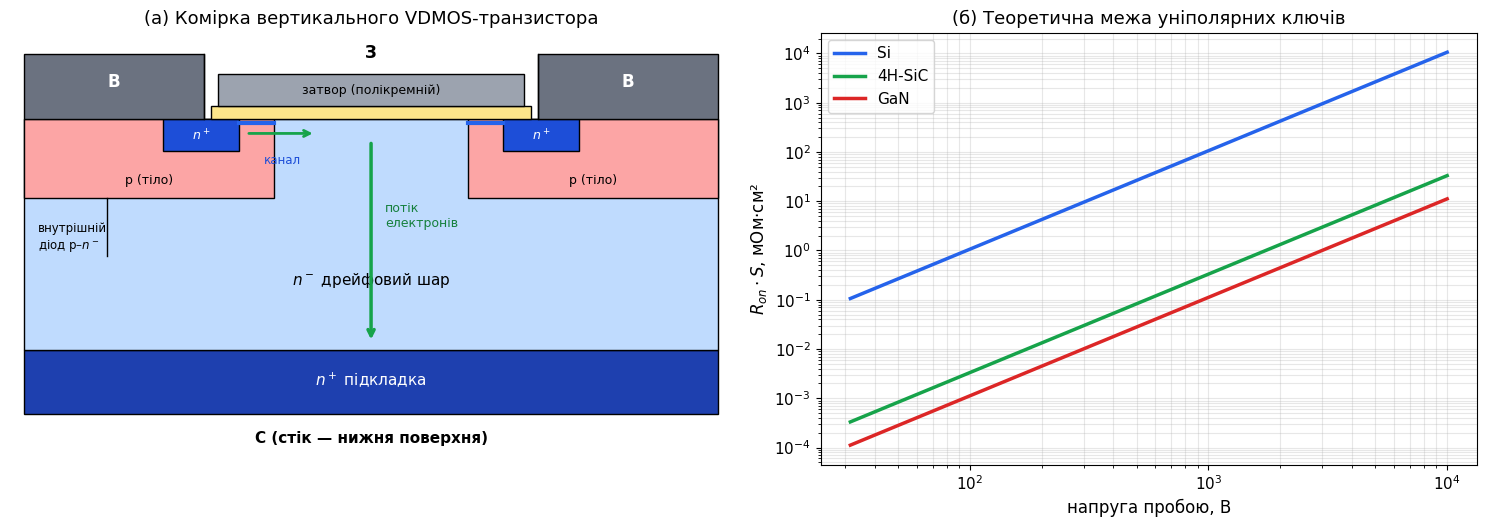

In [4]:
# (а) Переріз комірки VDMOS (не в масштабі); (б) кремнієва межа та широкозонні матеріали: R_on,sp = 4·U_BR²/(ε·μ·E_c³)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.4), gridspec_kw=dict(width_ratios=[1.1, 1]))
ax = axes[0]
R = lambda x, y, w, h, fc, **kw: ax.add_patch(patches.Rectangle((x, y), w, h, fc=fc, ec='k', lw=1, **kw))
R(0, 0, 10, 0.9, '#1e40af'); ax.text(5, 0.4, '$n^+$ підкладка', ha='center', color='white')
R(0, 0.9, 10, 3.2, '#bfdbfe'); ax.text(5, 1.8, '$n^-$ дрейфовий шар', ha='center')
for x0 in [0, 6.4]:
    R(x0, 3.0, 3.6, 1.1, '#fca5a5'); ax.text(x0 + 1.8, 3.2, 'p (тіло)', ha='center', fontsize=9)
for x0 in [2.0, 6.9]:
    R(x0, 3.65, 1.1, 0.45, '#1d4ed8'); ax.text(x0 + 0.55, 3.8, '$n^+$', ha='center', color='white', fontsize=9)
R(2.7, 4.1, 4.6, 0.18, '#fde68a'); R(2.8, 4.28, 4.4, 0.45, '#9ca3af'); ax.text(5, 4.45, 'затвор (полікремній)', ha='center', fontsize=9)
R(0, 4.1, 2.6, 0.9, '#6b7280'); R(7.4, 4.1, 2.6, 0.9, '#6b7280')
ax.plot([2.6, 2.6], [4.1, 5.0], 'k', lw=1); ax.plot([7.4, 7.4], [4.1, 5.0], 'k', lw=1)
ax.text(1.3, 4.55, 'В', ha='center', fontsize=12, color='white', fontweight='bold'); ax.text(8.7, 4.55, 'В', ha='center', fontsize=12, color='white', fontweight='bold')
ax.text(5, 4.95, 'З', ha='center', fontsize=12, fontweight='bold'); ax.text(5, -0.4, 'С (стік — нижня поверхня)', ha='center', fontsize=11, fontweight='bold')
for xc in [3.35, 6.65]:
    ax.plot([xc - 0.25, xc + 0.25], [4.05, 4.05], color='#2563eb', lw=3)
ax.annotate('', xy=(4.2, 3.9), xytext=(3.2, 3.9), arrowprops=dict(arrowstyle='->', color='#16a34a', lw=2))
ax.annotate('', xy=(5, 1.0), xytext=(5, 3.8), arrowprops=dict(arrowstyle='->', color='#16a34a', lw=2.5))
ax.text(5.2, 2.6, 'потік\nелектронів', color='#15803d', fontsize=9)
ax.text(3.45, 3.47, 'канал', color='#1d4ed8', fontsize=8.5)
ax.plot([1.2, 1.2], [3.0, 2.2], 'k', lw=1); ax.text(0.2, 2.3, 'внутрішній\nдіод p–$n^-$', fontsize=8.5)
ax.set_xlim(-0.2, 10.2); ax.set_ylim(-0.7, 5.3); ax.axis('off'); ax.set_title('(а) Комірка вертикального VDMOS-транзистора')
ax = axes[1]
U = np.logspace(1.5, 4, 100)
for name, eps_r, mu, Ec, col in [('Si', 11.7, 1350, 3e5, '#2563eb'), ('4H-SiC', 9.7, 900, 2.5e6, '#16a34a'), ('GaN', 9.0, 1250, 3.3e6, '#dc2626')]:
    Ron = 4*U**2/(eps_r*eps0*1e-2*mu*Ec**3)            # Ом·см²
    ax.loglog(U, Ron*1e3, color=col, lw=2.5, label=name)
ax.set_xlabel('напруга пробою, В'); ax.set_ylabel('$R_{on}\\cdot S$, мОм·см²'); ax.grid(True, which='both', alpha=0.3)
ax.set_title('(б) Теоретична межа уніполярних ключів'); ax.legend()
plt.tight_layout(); plt.show()

Широкозонні матеріали мають у 8–10 разів більше критичне поле пробою $E_c$. Тому при тій самій напрузі дрейфовий шар може бути в 10 разів тоншим і в 100 разів сильніше легованим, а питомий опір увімкненого стану — на два–три порядки меншим. **SiC-МДН-транзистори** (650–3300 В) витісняють кремнієві IGBT в інверторах електромобілів і сонячних станцій. **GaN-транзистори з високою рухливістю електронів (HEMT)** (до 650 В) працюють на частотах у мегагерци в компактних зарядних пристроях.

---

# IGBT — біполярний транзистор з ізольованим затвором <a class="anchor" id="igbt"></a>

**IGBT** поєднує МДН-керування (напругою, без статичного струму затвора) з **біполярною провідністю** великого струму. Структурно це VDMOS, у якому $n^+$-підкладку замінено на **$p^+$-колектор**. Виникає ще один p-n перехід ($p^+$–$n^-$), який при ввімкненні **інжектує дірки** в дрейфовий шар. Концентрація носіїв у шарі $n^-$ зростає на кілька порядків (**модуляція провідності**), і його опір різко падає. Тому при високих напругах IGBT має значно менший спад напруги, ніж МДН-транзистор тієї самої площі. $U_{КЕ.нас}$ = 1,5–3 В майже не залежить від номінальної напруги приладу.

**Еквівалентна схема:** n-МДН-транзистор, що керує струмом бази широкобазового **p-n-p** транзистора (емітер p-n-p — колектор IGBT). У структурі є також паразитний n-p-n транзистор ($n^+$ витік – p тіло – $n^-$), який разом з p-n-p утворює **паразитний тиристор**. Якщо струм перевищить допустимий, тиристор вмикається — **защіпання** (latch-up), і затвор втрачає керування. У сучасних IGBT защіпання усунуто конструктивно (шунтування p-тіла, мала ширина $n^+$).

**Недоліки**, породжені біполярною природою:

- **пороговий спад напруги** ≈ 0,7 В (прямозміщений $p^+$–$n^-$ перехід): при малих струмах IGBT програє МДН-транзистору;
- **«хвіст» струму при вимиканні**: після закриття МДН-каналу надлишковий заряд у дрейфовому шарі зникає лише рекомбінацією — струм спадає повільно (сотні нс – мкс), що збільшує енергію вимикання й обмежує частоту до ≈ 20–50 кГц;
- **немає внутрішнього діода**, тому зустрічно-паралельний діод вбудовують у корпус (co-pack).

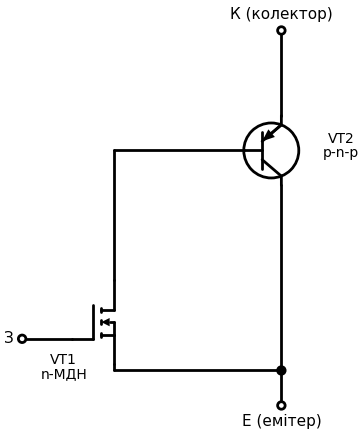

In [5]:
# Еквівалентна схема IGBT: МДН + p-n-p (+ паразитний n-p-n → тиристор)
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=11, unit=2) as d:
        qp = d.add(elm.BjtPnp(circle=True).at((2.6, 3.8)).theta(0))            # у p-n-p схемдро емітер угорі
        d.add(elm.Line().endpoints(qp.emitter, (qp.emitter[0], 6.2)))
        d.add(elm.Dot(open=True).at((qp.emitter[0], 6.2)).label('К (колектор)', loc='top'))
        d.add(elm.Label().at((qp.center[0] + 1.3, qp.center[1])).label('VT2\np-n-p', fontsize=10))
        m = d.add(elm.NMos().at((0.0, 1.2)).theta(0))
        d.add(elm.Line().endpoints(qp.base, (m.drain[0], qp.base[1]))); d.add(elm.Line().endpoints((m.drain[0], qp.base[1]), m.drain))
        d.add(elm.Line().endpoints(m.gate, (m.gate[0] - 1.0, m.gate[1]))); d.add(elm.Dot(open=True).at((m.gate[0] - 1.0, m.gate[1])).label('З', loc='left'))
        d.add(elm.Line().endpoints(m.source, (m.source[0], -0.6)))
        d.add(elm.Line().endpoints(qp.collector, (qp.collector[0], -0.6)))
        d.add(elm.Line().endpoints((m.source[0], -0.6), (qp.collector[0], -0.6))); d.add(elm.Dot().at((qp.collector[0], -0.6)))
        d.add(elm.Line().endpoints((qp.collector[0], -0.6), (qp.collector[0], -1.3))); d.add(elm.Dot(open=True).at((qp.collector[0], -1.3)).label('Е (емітер)', loc='bottom'))
        d.add(elm.Label().at((m.center[0] - 1.1, m.center[1] - 0.8)).label('VT1\nn-МДН', fontsize=10))

Позначення: струм «колектор → емітер» IGBT тече через емітерний перехід p-n-p транзистора VT2 (частина струму йде колектором VT2, частина — через його базу й канал МДН-транзистора VT1). Коефіцієнт передачі широкобазового p-n-p навмисно малий ($\alpha_{pnp}$ ≈ 0,3–0,4), щоб не виникало защіпання.

### ⚙️ PySpice: вихідні характеристики IGBT і МДН-транзистора <a class="anchor" id="spice-igbt-dc"></a>

IGBT **IRG4BC20U** (600 В, 13 А; модель International Rectifier) і МДН-транзистор **IRF540** (100 В, 28 А). Зверніть увагу на «поріг» ≈ 0,7 В на характеристиках IGBT (прямий перехід колектора) і на лінійну (резистивну) початкову ділянку МДН-транзистора.

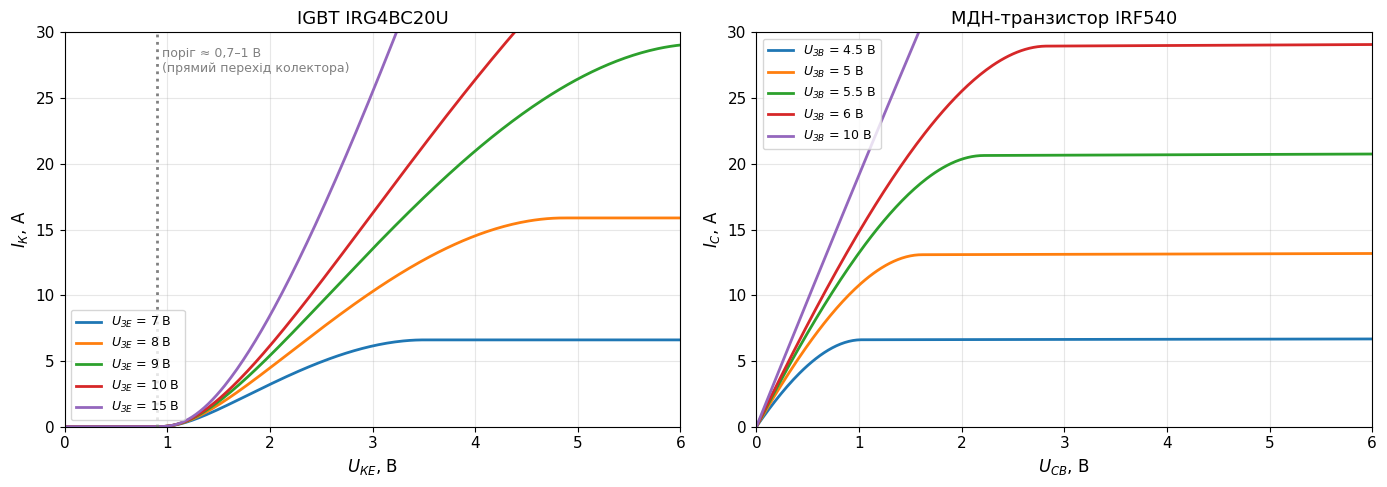

IRG4BC20U: U_КЕ.нас при 6,5 А і U_ЗЕ = 15 В: 1.86 В (паспорт: 1,85 В)


In [6]:
def dc_family(libname, sub, Ug_list, Umax=10):
    c = Circuit('dc'); c.include(lib(libname)); c.V('g', 'g', c.gnd, 0); c.V('d', 'd', c.gnd, 0); c.X(1, sub, 'd', 'g', c.gnd)
    out = []
    for ug in Ug_list:
        c['Vg'].dc_value = ug; an = c.simulator().dc(Vd=slice(0, Umax, 0.02))
        out.append((ug, np.array(an.sweep), -np.array(an.branches['vd'])))
    return out
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ug, U, I in dc_family('igbt', 'irg4bc20u_IR', [7, 8, 9, 10, 15]):
    axes[0].plot(U, I, lw=2, label=f'$U_{{ЗЕ}}$ = {ug} В')
axes[0].set_xlim(0, 6); axes[0].set_ylim(0, 30); axes[0].set_xlabel('$U_{КЕ}$, В'); axes[0].set_ylabel('$I_К$, А'); axes[0].legend(fontsize=9)
axes[0].set_title('IGBT IRG4BC20U'); axes[0].axvline(0.9, color='gray', ls=':'); axes[0].text(0.95, 27, 'поріг ≈ 0,7–1 В\n(прямий перехід колектора)', color='gray', fontsize=9)
for ug, U, I in dc_family('mosfet', 'irf540_IR', [4.5, 5, 5.5, 6, 10]):
    axes[1].plot(U, I, lw=2, label=f'$U_{{ЗВ}}$ = {ug} В')
axes[1].set_xlim(0, 6); axes[1].set_ylim(0, 30); axes[1].set_xlabel('$U_{СВ}$, В'); axes[1].set_ylabel('$I_С$, А'); axes[1].legend(fontsize=9)
axes[1].set_title('МДН-транзистор IRF540')
plt.tight_layout(); plt.show()
c = Circuit('vsat'); c.include(lib('igbt')); c.I('c', c.gnd, 'c', 6.5); c.V('g', 'g', c.gnd, 15); c.X(1, 'irg4bc20u_IR', 'c', 'g', c.gnd)
print(f'IRG4BC20U: U_КЕ.нас при 6,5 А і U_ЗЕ = 15 В: {float(c.simulator().operating_point()["c"][0]):.2f} В (паспорт: 1,85 В)')

### ⚙️ PySpice: вимикання IGBT і МДН-транзистора — «хвіст» струму <a class="anchor" id="spice-igbt-tail"></a>

Для перехідних процесів використано **узагальнену модель IGBT** `IGBT_GEN` з `models/igbt.lib`, побудовану за наведеною еквівалентною схемою: n-МДН-транзистор + широкобазовий p-n-p з часом прольоту $\tau_F$ = 250 нс. Детальна модель IRG4BC20U в ngspice при вимиканні не сходиться. Навантаження — 10 Ом від 100 В, драйвер 0/15 В через $R_З$ = 10 Ом.

In [7]:
def turn_off(show_mosfet=True):
    res = {}
    for name, libname, sub in [('IGBT (узагальнена модель)', 'igbt', 'IGBT_GEN'), ('МДН IRF540', 'mosfet', 'irf540_IR')]:
        if name.startswith('МДН') and not show_mosfet: continue
        c = Circuit('turn-off'); c.include(lib(libname))
        c.PulseVoltageSource('dr', 'dr', c.gnd, initial_value=0, pulsed_value=15, delay_time=1e-6, rise_time=10e-9, fall_time=10e-9,
                             pulse_width=10e-6, period=40e-6)
        c.R('g', 'dr', 'g', 10); c.V('dd', 'vdd', c.gnd, 100); c.R('L', 'vdd', 'd', 10); c.X(1, sub, 'd', 'g', c.gnd)
        an = tran_checked(c.simulator(), 14e-6, step_time=2e-9, max_time=5e-9)
        t = np.array(an.time); i = (100 - np.array(an['d']))/10; u = np.array(an['d'])
        res[name] = (t, i, u)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
    for (name, (t, i, u)), col in zip(res.items(), ['#dc2626', '#2563eb']):
        axes[0].plot((t - 11e-6)*1e9, i, color=col, lw=2, label=name)
        axes[1].plot((t - 11e-6)*1e9, u*i, color=col, lw=2, label=name)
        m = (t > 11e-6)
        ion = np.interp(10.9e-6, t, i); k = np.where(m & (i < 0.02*ion))[0]
        E = np.trapezoid((u*i)[m], t[m])
        print(f'{name}: струм у ввімкненому стані {ion:.2f} А, спад напруги {np.interp(10.9e-6, t, u):.2f} В, '
              f'спад струму до 2 % за {(t[k[0]] - 11e-6)*1e9:.0f} нс, енергія вимикання {E*1e6:.1f} мкДж')
    axes[0].set_xlim(-50, 900); axes[0].set_xlabel('t після зняття сигналу, нс'); axes[0].set_ylabel('$i_К$, А'); axes[0].legend()
    axes[0].annotate('«хвіст» струму — рекомбінація\nзаряду в дрейфовому шарі', xy=(300, 1.0), xytext=(350, 4.5), arrowprops=dict(arrowstyle='->'), fontsize=9)
    axes[0].set_title('Струм при вимиканні')
    axes[1].set_xlim(-50, 900); axes[1].set_xlabel('t, нс'); axes[1].set_ylabel('p = u·i, Вт'); axes[1].legend(); axes[1].set_title('Миттєва потужність втрат')
    plt.tight_layout(); plt.show()

interact(turn_off, show_mosfet=widgets.Checkbox(value=True, description='показати МДН-транзистор для порівняння'));

interactive(children=(Checkbox(value=True, description='показати МДН-транзистор для порівняння'), Output()), _…

---

# Порівняння силових ключів <a class="anchor" id="switch-comparison"></a>

| Параметр | Біполярний (БТ) | МДН (Si) | IGBT | SiC-МДН | GaN HEMT |
|---|---|---|---|---|---|
| Керування | струмом бази | напругою | напругою | напругою | напругою |
| Спад напруги у ввімкненому стані | $U_{КЕ.нас}$ 0,2–1 В | $I\cdot R_{DS(on)}$ (росте з $U_{проб}$) | 1,5–3 В | $I\cdot R_{DS(on)}$ (малий) | $I\cdot R_{DS(on)}$ |
| Напруга | до 1500 В | до 900 В | 600–6500 В | 650–3300 В | до 650 В |
| Частота перемикань | до 10–20 кГц | 100 кГц – кілька МГц | 5–50 кГц | 50–500 кГц | 0,1–10 МГц |
| Недоліки | накопичення заряду, вторинний пробій, потужний драйвер бази | великий $R_{on}$ при високих напругах | «хвіст», поріг 0,7 В | ціна, чутливий затвор | ціна, напруга ≤ 650 В |

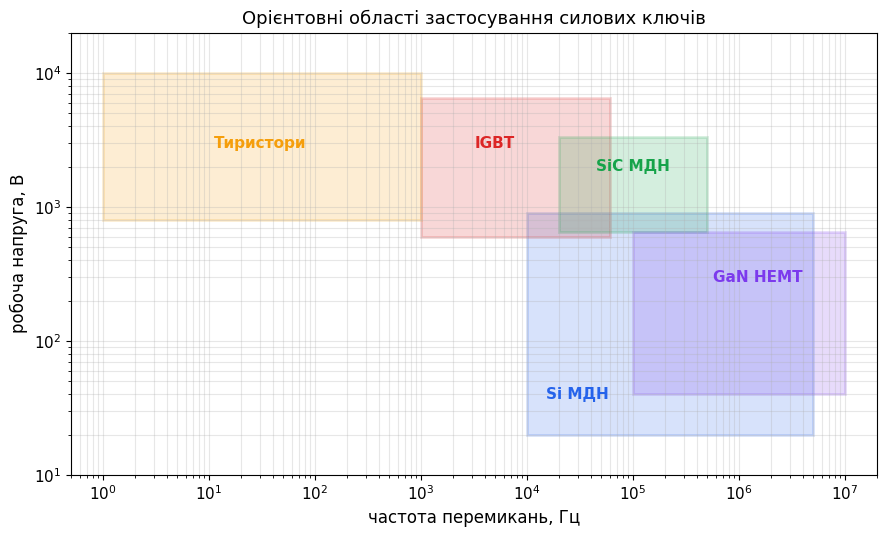

In [8]:
fig, ax = plt.subplots(figsize=(9, 5.5))
regions = [('Si МДН', 1e4, 5e6, 20, 900, '#2563eb', (3e4, 40)), ('IGBT', 1e3, 6e4, 600, 6500, '#dc2626', (5e3, 3000)),
           ('SiC МДН', 2e4, 5e5, 650, 3300, '#16a34a', (1e5, 2000)), ('GaN HEMT', 1e5, 1e7, 40, 650, '#7c3aed', (1.5e6, 300)),
           ('Тиристори', 1, 1e3, 800, 10000, '#f59e0b', (30, 3000))]
for name, f0, f1, u0, u1, col, (xl, yl) in regions:
    ax.add_patch(patches.Rectangle((f0, u0), f1 - f0, u1 - u0, fc=col, alpha=0.18, ec=col, lw=2))
    ax.text(xl, yl, name, ha='center', va='center', fontsize=11, color=col, fontweight='bold')
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlim(0.5, 2e7); ax.set_ylim(10, 2e4)
ax.set_xlabel('частота перемикань, Гц'); ax.set_ylabel('робоча напруга, В'); ax.set_title('Орієнтовні області застосування силових ключів')
ax.grid(True, which='both', alpha=0.3); plt.tight_layout(); plt.show()

---
### ⚡ Практичне застосування: Де працюють силові ключі

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**МДН-транзистори** — імпульсні джерела живлення, DC/DC-перетворювачі на материнських платах (десятки ампер при 1 В), драйвери двигунів малої потужності, зарядні пристрої. **IGBT** — частотні перетворювачі асинхронних двигунів, зварювальні інвертори, індукційні плити, тяговий привод електропоїздів, ДБЖ. **SiC** — інвертори електромобілів (800 В), сонячні інвертори, швидкі зарядні станції. **GaN** — компактні USB-C зарядні пристрої (понад 100 Вт у кишеньковому корпусі), лідари, НВЧ-підсилювачі базових станцій.

</div>

---
### ✅ Питання для самоперевірки: Динамічні властивості ПТ, потужні МДН і IGBT

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому на осцилограмі $u_{ЗВ}$ під час перемикання з'являється горизонтальне плато?</summary>

> **Відповідь:** Поки змінюється напруга стоку, струм драйвера йде на перезаряд ємності затвор–стік $C_{ЗС}$ (ефект Міллера). Струм стоку в цей час заданий навантаженням, тому напруга затвора залишається на рівні $U_{пор} + I_С/g_m$, доки перепад $U_{СВ}$ не завершиться.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Чому $R_{DS(on)}$ кремнієвих МДН-транзисторів різко зростає з номінальною напругою?</summary>

> **Відповідь:** Для вищої напруги потрібен товщий і слабше легований дрейфовий шар; питомий опір $R_{on}S \propto U_{проб}^{2{,}5}$. У високовольтних приладах цей шар дає переважну частину опору.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Завдяки чому IGBT на 1200 В має малий спад напруги при великому струмі?</summary>

> **Відповідь:** Колекторний $p^+$ шар інжектує дірки в дрейфовий $n^-$ шар, концентрація носіїв там зростає на порядки (модуляція провідності), і опір шару падає. Спад напруги — ≈0,7 В на переході плюс малий опір модульованого шару.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 4.</b> Чому IGBT вимикається повільніше за МДН-транзистор?</summary>

> **Відповідь:** Після закриття каналу в дрейфовому шарі залишається накопичений заряд неосновних носіїв (дірок), який не може бути виведений затвором і зникає рекомбінацією. Звідси «хвіст» струму і додаткова енергія вимикання.

</details>

---
### 📝 Задачі для самостійного розв'язання: Силові ключі


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** МДН-транзистор має $Q_g$ = 60 нКл при $U_{драйв}$ = 12 В і працює з частотою 100 кГц. Яку потужність віддає драйвер? Який середній струм він споживає?

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $P_{др} = Q_gU_{драйв}f = 60\cdot10^{-9}\cdot12\cdot10^5 = 72$ мВт; середній струм $Q_gf = 6$ мА (імпульсний — амперами).

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** Ключ комутує 10 А при 100 В з частотою 50 кГц; час ввімкнення і вимкнення по 100 нс (резистивне навантаження, $E \approx UIt/6$); $R_{DS(on)}$ = 52 мОм; коефіцієнт заповнення 0,5. Оцініть втрати.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> Статичні: $I^2R\cdot D = 100\cdot0{,}052\cdot0{,}5 = 2{,}6$ Вт; динамічні: $2\cdot\frac{100\cdot10\cdot10^{-7}}{6}\cdot5\cdot10^4 = 1{,}67$ Вт; разом ≈ 4{,}3 Вт.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 3.** Порівняйте статичні втрати при струмі 20 А: IGBT з $U_{КЕ.нас}$ = 1,8 В і МДН-транзистора на 600 В з $R_{DS(on)}$ = 0,19 Ом.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> IGBT: $1{,}8\cdot20 = 36$ Вт; МДН: $20^2\cdot0{,}19 = 76$ Вт. При великих струмах і напругах IGBT вигідніший; при струмі 5 А: IGBT ≈ 7 Вт (поріг!), МДН ≈ 4,8 Вт — вигідніший МДН.

</details>

---

## 📌 Підсумок лекції 10: Динамічні властивості ПТ, потужні МДН-транзистори та IGBT <a class="anchor" id="summary"></a>

<div style="background-color: #f0fdf4; padding: 24px 18px; border-radius: 10px; border-left: 4px solid #16a34a; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

| Прилад | Ключова особливість | Головне обмеження |
|---|---|---|
| МДН-транзистор (динаміка) | перемикання = перезаряд $C_{iss}$, $C_{rss}$; плато Міллера | потрібен потужний драйвер затвора |
| VDMOS | вертикальна структура, внутрішній діод, додатний ТКС $R_{on}$ | $R_{on}S \propto U_{проб}^{2,5}$ |
| SiC / GaN | у 10 разів більше критичне поле | ціна, особливості керування |
| IGBT | модуляція провідності → малий спад при високих напругах | поріг 0,7 В, «хвіст» струму, частота ≤ 50 кГц |

**Головні висновки.** (1) Швидкодія МДН-транзистора визначається перезарядом його ємностей; заряд затвора — зручна міра енергії керування. (2) Потужні вертикальні МДН-транзистори ідеальні для низьких і середніх напруг і високих частот. (3) IGBT поєднує МДН-вхід з біполярним виходом і домінує в потужних перетворювачах середньої частоти. (4) Широкозонні SiC і GaN розширюють межі «напруга–частота–ККД» силової електроніки.

</div>

---

## 📚 Рекомендована література та ресурси <a class="anchor" id="references"></a>

**Основна література**

1. Прищепа М. М., Погребняк В. П. Мікроелектроніка. Ч. 1. Елементи мікроелектроніки: навч. посібник. — К.: Вища школа, 2004.
2. Бойко В. І., Гуржій А. М., Жуйков В. Я. та ін. Схемотехніка електронних систем. Кн. 1. Аналогова схемотехніка та імпульсні пристрої. — К.: Вища школа, 2004.
3. Sze S. M., Ng K. K. Physics of Semiconductor Devices. — 3rd ed. — Wiley, 2007.
4. Neamen D. A. Semiconductor Physics and Devices: Basic Principles. — 4th ed. — McGraw-Hill, 2012.

**Додаткова література**

5. Sedra A. S., Smith K. C. Microelectronic Circuits. — 8th ed. — Oxford University Press, 2020.
6. Streetman B. G., Banerjee S. K. Solid State Electronic Devices. — 7th ed. — Pearson, 2016.

**Програмні інструменти, що використовуються в конспекті**

- [PySpice](https://pyspice.fabrice-salvaire.fr/) + [ngspice](https://ngspice.sourceforge.io/) — схемотехнічне моделювання (SPICE-моделі приладів — у теці `models/`)
- [SchemDraw](https://schemdraw.readthedocs.io/) — побудова електричних схем
- [NumPy](https://numpy.org/doc/) / [SciPy](https://docs.scipy.org/doc/scipy/) / [Matplotlib](https://matplotlib.org/) — чисельні розрахунки та графіки
- [ipywidgets](https://ipywidgets.readthedocs.io/) — інтерактивні елементи керування

---

<p style="text-align: center;">⬅️ [Лекція 9. МДН-транзистори (MOSFET)](Лекція_09_МДН-транзистори.ipynb) &nbsp;|&nbsp; [Лекція 11. Тиристорні прилади](Лекція_11_Тиристорні_прилади.ipynb) ➡️</p>

*Конспект підготовлено: Пахалюк Богдан Петрович, НУ "Чернігівська політехніка"*